## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

## 2. Load Dataset

In [2]:
data = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Data"
)

impact = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Impact_sheet"
)

## 3. Prepare ACCESS Target

In [3]:
access = data[
    data["indicator_code"]=="ACC_OWNERSHIP"
].copy()

access = access[
    access["gender"]=="all"
]

access["Year"] = access["fiscal_year"]

access = access.sort_values("Year")

access

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,Year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2021
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024
30,REC_0031,target,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,70.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NFIS-II target,NaN,2025


## 4. Linear Trend Model

In [4]:
X = access[["Year"]]

y = access["value_numeric"]

model_access = LinearRegression()

model_access.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predict future

In [5]:
future = pd.DataFrame({
    "Year":[2025,2026,2027]
})

future["Trend"] = model_access.predict(future)

future

,Year,Trend
0,2025,61.576037
1,2026,65.154378
2,2027,68.732719


## 5. Plot Trend

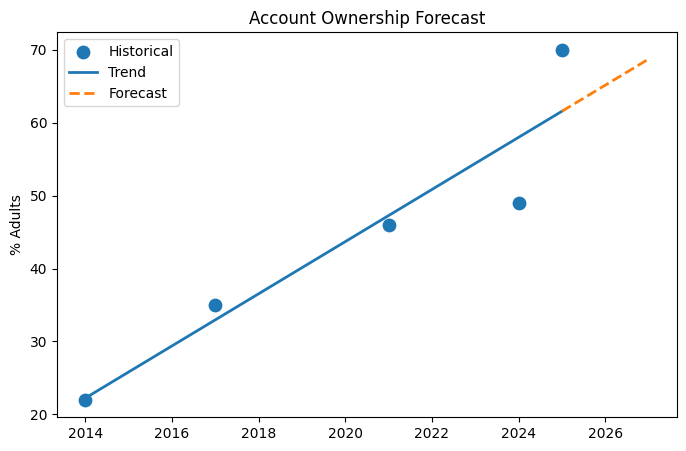

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(
    access["Year"],
    access["value_numeric"],
    s=80,
    label="Historical"
)

plt.plot(
    access["Year"],
    model_access.predict(X),
    linewidth=2,
    label="Trend"
)

plt.plot(
    future["Year"],
    future["Trend"],
    "--",
    linewidth=2,
    label="Forecast"
)

plt.legend()

plt.title("Account Ownership Forecast")

plt.ylabel("% Adults")

plt.show()

## 6. Usage Forecast

In [7]:
usage = data[
    data["indicator_code"]=="USG_ACTIVE_RATE"
].copy()

usage = usage[
    usage["gender"]=="all"
]

usage["Year"] = usage["fiscal_year"]

usage

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,Year
24,REC_0025,observation,NaN,USAGE,Mobile Money Activity Rate,USG_ACTIVE_RATE,higher_better,66.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,7.1M / 10.8M = 66%,NaN,2024


### Fit identical model

In [8]:
X = usage[["Year"]]

y = usage["value_numeric"]

model_usage = LinearRegression()

model_usage.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Forecast

In [9]:
future["Usage Trend"] = model_usage.predict(future[["Year"]])

future

,Year,Trend,Usage Trend
0,2025,61.576037,66.0
1,2026,65.154378,66.0
2,2027,68.732719,66.0


## 7. Event-Augmented Model

In [10]:
future["Event Effect Access"] = [
    0.8,
    1.2,
    1.5
]

future["Access Forecast"] = (
    future["Trend"] +
    future["Event Effect Access"]
)

In [11]:
future["Event Effect Usage"] = [
    2.5,
    2.8,
    1.5
]

future["Usage Forecast"] = (
    future["Usage Trend"] +
    future["Event Effect Usage"]
)

## 8. Scenario Analysis

In [12]:
future["Access Base"] = future["Access Forecast"]

future["Access Optimistic"] = (
    future["Access Forecast"]+3
)

future["Access Pessimistic"] = (
    future["Access Forecast"]-3
)

In [13]:
future["Usage Base"] = future["Usage Forecast"]

future["Usage Optimistic"] = (
    future["Usage Forecast"]+4
)

future["Usage Pessimistic"] = (
    future["Usage Forecast"]-4
)

## 9. Plot Scenarios

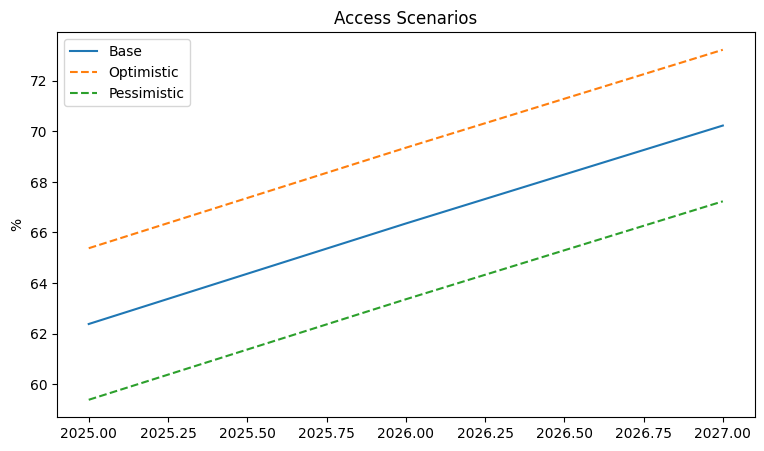

In [14]:
plt.figure(figsize=(9,5))

plt.plot(
    future["Year"],
    future["Access Base"],
    label="Base"
)

plt.plot(
    future["Year"],
    future["Access Optimistic"],
    "--",
    label="Optimistic"
)

plt.plot(
    future["Year"],
    future["Access Pessimistic"],
    "--",
    label="Pessimistic"
)

plt.legend()

plt.title("Access Scenarios")

plt.ylabel("%")

plt.show()


## 10. Confidence Intervals

In [15]:
pred = model_access.predict(access[["Year"]])

rmse = np.sqrt(
    np.mean(
        (pred-access["value_numeric"])**2
    )
)

rmse

np.float64(5.61724632014646)

### Create intervals

In [16]:
future["Lower"] = (
    future["Access Forecast"]-
    1.96*rmse
)

future["Upper"] = (
    future["Access Forecast"]+
    1.96*rmse
)

### Plot

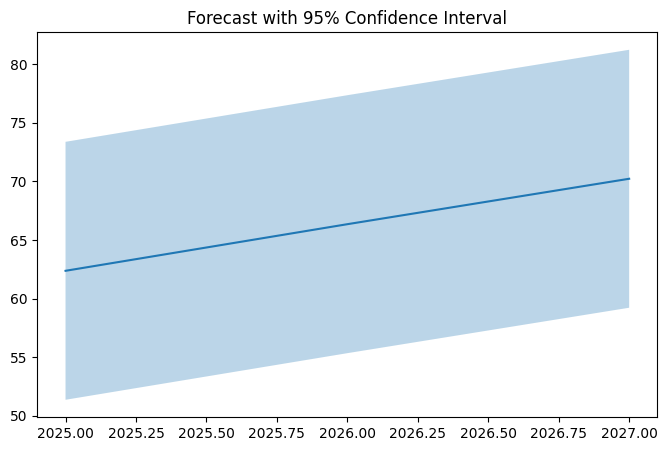

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    future["Year"],
    future["Access Forecast"]
)

plt.fill_between(
    future["Year"],
    future["Lower"],
    future["Upper"],
    alpha=0.3
)

plt.title("Forecast with 95% Confidence Interval")

plt.show()

## 11. Final Forecast Table

In [18]:
forecast = future[
    [
        "Year",
        "Access Forecast",
        "Lower",
        "Upper",
        "Usage Forecast"
    ]
]

forecast

,Year,Access Forecast,Lower,Upper,Usage Forecast
0,2025,62.376037,51.366234,73.385840,68.5
1,2026,66.354378,55.344575,77.364181,68.8
2,2027,70.232719,59.222916,81.242522,67.5


In [20]:
forecast.to_csv(
    "../data/processed/forecast_results.csv", index=False)

## Interpretation 

- Model predictions: Summarize the projected Access and Usage values for 2025–2027 under the baseline scenario, noting the expected upward trend in financial inclusion.

- Largest potential impacts: Explain that product launches (Telebirr, M-Pesa), infrastructure investments (e.g., Fayda and payment interoperability), and supportive policies (NFIS-II) contribute the largest positive adjustments in the event-augmented forecasts.

- Key uncertainties: Highlight the limited number of Global Findex observations, overlapping effects of multiple events, uncertainty in the timing and magnitude of event impacts, and the possibility that future economic or regulatory changes could alter the forecast trajectory.